# Build matrix of interactions

In [ ]:
import pandas as pd

df = pd.read_csv('protein_interactions.csv')

hydrophobic = df[df["interaction_type"] == "hydrophobic_contacts"].drop_duplicates(
    subset=["protein", "ligand", "residue_id", "interaction_type"]
)

other = df[df["interaction_type"] != "hydrophobic_contacts"]

df_nodup_hpb = pd.concat([hydrophobic, other], ignore_index=True)

df_nodup_hpb.to_csv('protein_interactions.csv', index=False)

In [33]:
import pandas as pd

df = pd.read_csv('protein_interactions.csv')
#df = pd.read_csv('/home/gbiuser/Documents/vitoria/usp-masters/8-docking/interactions/protein_interactions.csv')    
print(df.shape)
print(df.columns)

(3652, 47)
Index(['protein', 'ligand', 'binding_site', 'interaction_type', 'resnr',
       'restype', 'reschain', 'resnr_lig', 'restype_lig', 'reschain_lig',
       'dist', 'ligcoo', 'protcoo', 'sidechain', 'dist_h_a', 'dist_d_a',
       'don_angle', 'protisdon', 'donoridx', 'donortype', 'acceptoridx',
       'acceptortype', 'dist_a_w', 'dist_d_w', 'water_angle', 'water_idx',
       'acc_angle', 'protispos', 'lig_group', 'lig_idx_list', 'cent_dist',
       'angle', 'offset', 'type', 'protcharged', 'metalcoo', 'targetcoo',
       'metal_idx', 'metal_type', 'target_idx', 'target_type', 'coordination',
       'location', 'rms', 'geometry', 'complexnum', 'residue_id'],
      dtype='object')


In [2]:
df["protein"].value_counts()

protein
PDE4D_dimer        857
PDE4D_catalytic    635
PDE4D_monomer      582
PDE4B_monomer      534
PDE4B_catalytic    532
PDE4B_dimer        512
Name: count, dtype: int64

## Conserved residues across all complexes

In [59]:
# create df disconsindering ions
df_lig = df[df["binding_site"].str.startswith("UNL:")].copy()


In [8]:
# aggregate number of interactions based on number of proteins and ligands 
conserved = (
    df_lig.groupby("residue_id")
            .agg(
                n_proteins=("protein", "nunique"),
                n_ligands=("ligand", "nunique"),
                n_complexes=("protein", lambda x: len(set(zip(x, df.loc[x.index, "ligand"])))),
            )         
            .reset_index()
)

In [9]:
conserved.sort_values("n_complexes", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
39,PHE618:A,3,20,53
41,PHE674:A,3,20,52
28,ILE638:A,3,19,46
55,TYR405:A,3,20,46
27,ILE582:A,3,20,42
13,GLN671:A,3,18,41
4,ASN623:A,3,18,40
56,TYR461:A,3,18,35
18,HIS406:A,3,18,34
38,PHE586:A,3,19,33


In [10]:
conserved.sort_values("n_proteins", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
3,ASN567:A,3,16,30
4,ASN623:A,3,18,40
14,GLU476:A,3,3,5
11,GLN615:A,3,17,28
13,GLN671:A,3,18,41
8,ASP620:A,3,12,19
7,ASP564:A,3,16,23
28,ILE638:A,3,19,46
21,HIS450:A,3,9,10
22,HIS462:A,3,16,31


### Conserved only in PDE4B

In [60]:
PDE4B_subset = [
    "PDE4B_dimer",
    "PDE4B_monomer",
    "PDE4B_catalytic"
]

df_subset = df[
    df["protein"].isin(PDE4B_subset)
].copy()

conserved_PDE4B = (
    df_subset.groupby("residue_id")
             .agg(
                 n_proteins=("protein", "nunique"),
                 n_ligands=("ligand", "nunique"),
                 n_complexes=("protein", lambda x: len(set(zip(x, df_subset.loc[x.index, "ligand"]))))
             )
             .reset_index()
             .sort_values(
                 ["n_proteins", "n_ligands"],
                 ascending=False
             )
)



In [61]:
conserved_PDE4B.head(30)

,residue_id,n_proteins,n_ligands,n_complexes
12,HIS446:A,3,20,60
17,ILE582:A,3,20,42
23,PHE618:A,3,20,53
30,TYR405:A,3,20,43
22,PHE586:A,3,19,33
10,HIS406:A,3,18,34
5,ASP564:A,3,17,24
7,GLN615:A,3,17,28
1,ASN567:A,3,16,33
20,MET519:A,3,10,13


# types analysis

In [9]:
df_lig.columns

Index(['protein', 'ligand', 'binding_site', 'interaction_type',
       'residue_number', 'residue_name', 'residue_chain', 'residue_id'],
      dtype='object')

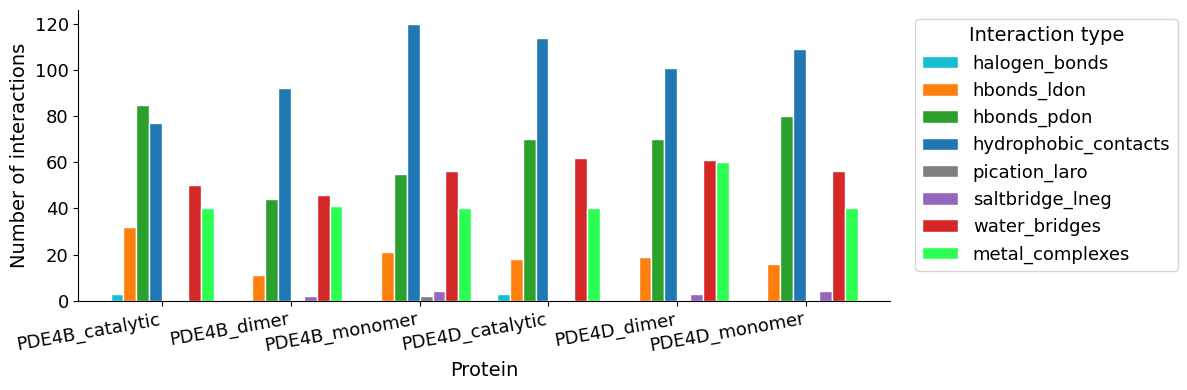

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

colors = {
    "hydrophobic_contacts": "#1f77b4",
    "hbonds_ldon": "#ff7f0e",
    "hbonds_pdon": "#2ca02c",
    "water_bridges": "#d62728",
    "saltbridge_lneg": "#9467bd",
    "saltbridge_pneg": "#8c564b",
    "pistacking": "#e377c2",
    "pication_laro": "#7f7f7f",
    "pication_paro": "#bcbd22",
    "halogen_bonds": "#17becf",
    "metal_complexes": "#2bff52",}

counts = (
    df[df["interaction_type"] != "metal_complexes"]
    .groupby(["protein", "interaction_type"])
    .size()
    .unstack(fill_value=0))

# Count unique ligand-metal complexes
metal_counts = (
    df[df["interaction_type"] == "metal_complexes"]
    [["protein", "ligand", "binding_site"]]
    .drop_duplicates()
    .groupby("protein")
    .size()
)

counts["metal_complexes"] = metal_counts
counts = counts.fillna(0)

ax = counts.plot(
    kind="bar",
    figsize=(12, 4),
    width=0.8,
    color=[colors.get(i, "#333333") for i in counts.columns],
    edgecolor="white",
    linewidth=1
)

ax.set_xlabel("Protein", fontsize=14)
ax.set_ylabel("Number of interactions", fontsize=14)

ax.tick_params(axis="both", labelsize=13)

ax.legend(
    title="Interaction type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=13,
    title_fontsize=14
)

plt.xticks(rotation=10, ha="right", fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
counts

interaction_type,halogen_bonds,hbonds_ldon,hbonds_pdon,hydrophobic_contacts,pication_laro,saltbridge_lneg,water_bridges,metal_complexes
protein,,,,,,,,
PDE4B_catalytic,3,32,85,77,0,0,50,40
PDE4B_dimer,0,11,44,92,0,2,46,41
PDE4B_monomer,0,21,55,120,2,4,56,40
PDE4D_catalytic,3,18,70,114,0,0,62,40
PDE4D_dimer,0,19,70,101,0,3,61,60
PDE4D_monomer,0,16,80,109,0,4,56,40


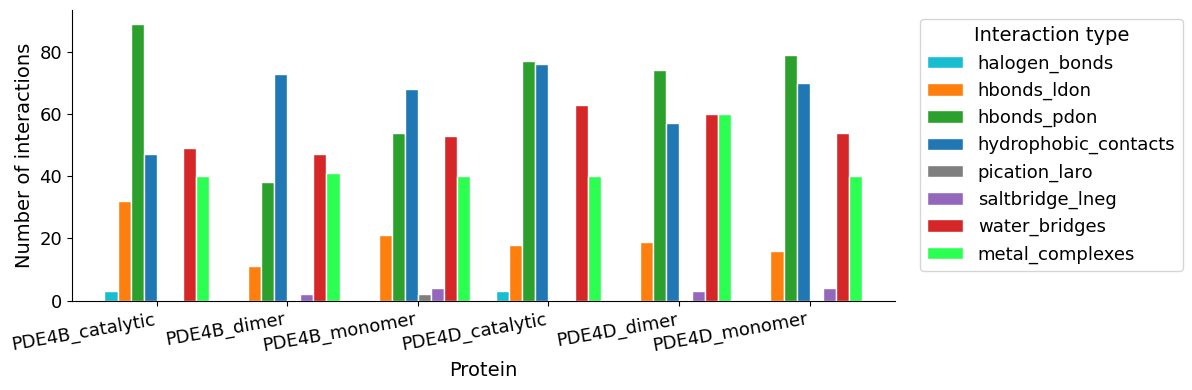

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

colors = {
    "hydrophobic_contacts": "#1f77b4",
    "hbonds_ldon": "#ff7f0e",
    "hbonds_pdon": "#2ca02c",
    "water_bridges": "#d62728",
    "saltbridge_lneg": "#9467bd",
    "saltbridge_pneg": "#8c564b",
    "pistacking": "#e377c2",
    "pication_laro": "#7f7f7f",
    "pication_paro": "#bcbd22",
    "halogen_bonds": "#17becf",
    "metal_complexes": "#2bff52",}

counts = (
    df_nodup_hpb[df_nodup_hpb["interaction_type"] != "metal_complexes"]
    .groupby(["protein", "interaction_type"])
    .size()
    .unstack(fill_value=0))

# Count unique ligand-metal complexes
metal_counts = (
    df_nodup_hpb[df_nodup_hpb["interaction_type"] == "metal_complexes"]
    [["protein", "ligand", "binding_site"]]
    .drop_duplicates()
    .groupby("protein")
    .size()
)

counts["metal_complexes"] = metal_counts
counts = counts.fillna(0)

ax = counts.plot(
    kind="bar",
    figsize=(12, 4),
    width=0.8,
    color=[colors.get(i, "#333333") for i in counts.columns],
    edgecolor="white",
    linewidth=1
)

ax.set_xlabel("Protein", fontsize=14)
ax.set_ylabel("Number of interactions", fontsize=14)

ax.tick_params(axis="both", labelsize=13)

ax.legend(
    title="Interaction type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=13,
    title_fontsize=14
)

plt.xticks(rotation=10, ha="right", fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### checking different types

In [22]:
import pandas as pd

pde4b_water_bridges = df.loc[
    df["protein"].str.startswith("PDE4B")
    & df["interaction_type"].eq("water_bridges")
].copy()

pde4b_water_bridges = pde4b_water_bridges[
        ["protein", "ligand", "resnr", "restype", "reschain"]
    ].drop_duplicates().sort_values(["protein", "ligand", "resnr"])

In [16]:
pde4b_water_bridges[pde4b_water_bridges["restype"] == "HIS"]

,protein,ligand,resnr,restype,reschain
147,PDE4B_catalytic,10176710,446,HIS,A
144,PDE4B_catalytic,10176710,450,HIS,A
284,PDE4B_catalytic,10394,410,HIS,A
200,PDE4B_catalytic,689043,410,HIS,A
366,PDE4B_catalytic,m1,450,HIS,A
338,PDE4B_catalytic,m2,410,HIS,A
420,PDE4B_catalytic,m4,410,HIS,A
418,PDE4B_catalytic,m4,450,HIS,A
474,PDE4B_catalytic,m5,410,HIS,A
475,PDE4B_catalytic,m5,446,HIS,A


In [21]:
import pandas as pd

pde4b_hydrophobic_contacts = df.loc[
    df["protein"].str.startswith("PDE4B")
    & df["interaction_type"].eq("hydrophobic_contacts")
].copy()

pde4b_hydrophobic_contacts = pde4b_hydrophobic_contacts[
        ["protein", "ligand", "resnr", "restype", "reschain"]
    ].drop_duplicates().sort_values(["protein", "ligand", "resnr"])

In [18]:
pde4b_hydrophobic_contacts["restype"].value_counts()

restype
PHE    86
ILE    42
TYR    21
MET    19
HIS    10
SER     7
LEU     3
Name: count, dtype: int64

In [23]:
import pandas as pd

hbonds_pdon = df.loc[
    df["protein"].str.startswith("PDE4B")
    & df["interaction_type"].eq("hbonds_pdon")
].copy()

hbonds_pdon["restype"].value_counts()

restype
GLN    52
HIS    42
ASN    39
TYR    20
GLU    10
THR     9
SER     6
MET     4
ASP     1
TRP     1
Name: count, dtype: int64

### metal

In [72]:
import re

PDE4B_subset = [
    "PDE4B_dimer",
    "PDE4B_monomer",
    "PDE4B_catalytic"
]

df_subset = df[
    df["protein"].isin(PDE4B_subset)
].copy()

ion_res = df_subset[df_subset["interaction_type"].eq("metal_complexes")].copy()
ion_res = ion_res.drop_duplicates(
    subset=["protein", "ligand", "binding_site", "residue_id", "resnr", "restype", "reschain"]
)

#ion_res = ion_res[ion_res["reschain"] != "B"]

def classify_metal(row):
    text = f"{row['ligand']} {row['binding_site']}".upper()
    # stronger search than \bZN\b or \bMG\b
    has_zn = bool(re.search(r"ZN|ZINC", text))
    has_mg = bool(re.search(r"MG|MAGNESIUM", text))

    if has_zn and has_mg:
        return "both"
    elif has_zn:
        return "Zn"
    elif has_mg:
        return "Mg"
    else:
        return "unknown"

ion_res["metal_involved"] = ion_res.apply(classify_metal, axis=1)

# aggregate all metals seen for each residue_id
residue_metal = (
    ion_res.groupby("residue_id", as_index=False)
    .agg(
        metal_involved=("metal_involved", lambda s: sorted(set(s))),
        n_proteins=("protein", "nunique"),
        n_ligands=("ligand", "nunique"),
        n_complexes=("protein", lambda x: len(set(zip(x, ion_res.loc[x.index, "ligand"]))))
    )
    .sort_values(["n_proteins", "n_ligands"], ascending=False)
)

# convert the list of labels into a single residue-wise class
def combine_metals(metals):
    metals = set(metals)
    if {"Zn", "Mg"}.issubset(metals):
        return "both"
    elif "Zn" in metals:
        return "Zn"
    elif "Mg" in metals:
        return "Mg"
    elif "unknown" in metals:
        return "unknown"
    else:
        return "none"

residue_metal["metal_involved"] = residue_metal["metal_involved"].apply(combine_metals)

residue_metal.sort_values("n_proteins", ascending=False)

,residue_id,metal_involved,n_proteins,n_ligands,n_complexes
3,HIS446:A,Zn,3,20,60
7,UNL1:Z,Mg,2,2,2
0,ASP386:A,Zn,1,20,20
1,ASP447:A,Mg,1,20,20
2,HIS410:A,Zn,1,20,20
4,HIS446:B,Zn,1,20,20
5,HOH1118:A,Zn,1,20,20
6,HOH788:A,both,1,20,20


In [73]:
ion_residue_table[ion_residue_table["residue_id"] == "UNL1:Z"]

,residue_id,resnr,restype,reschain,protein,ligand,binding_site
3,UNL1:Z,1,UNL,Z,PDE4B_catalytic,10176710,MG:A:804
616,UNL1:Z,1,UNL,Z,PDE4B_dimer,10559720,MG:A:804


In [ ]:
# test to find 274 etc

from plip.structure.preparation import PDBComplex

import os
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
from plip.structure.preparation import PDBComplex

# Protein names (longest first to avoid partial matches)
proteins = [
    "PDE4B_catalytic",
    "PDE4B_monomer",
    "PDE4B_dimer",
    "PDE4D_catalytic",
    "PDE4D_monomer",
    "PDE4D_dimer"
]

interaction_types = [
    "hydrophobic_contacts",
    "hbonds_ldon",
    "hbonds_pdon",
    "water_bridges",
    "saltbridge_lneg",
    "saltbridge_pneg",
    "pistacking",
    "pication_laro",
    "pication_paro",
    "halogen_bonds",
    "metal_complexes",
]

# All PLIP interaction attributes to extract
interaction_attributes = [
    # General
    "resnr",
    "restype",
    "reschain",
    "resnr_lig",
    "restype_lig",
    "reschain_lig",
    "dist",
    "ligcoo",
    "protcoo",

    # Hydrogen bonds
    "sidechain",
    "dist_h_a",
    "dist_d_a",
    "don_angle",
    "protisdon",
    "donoridx",
    "donortype",
    "acceptoridx",
    "acceptortype",

    # Water bridges
    "dist_a_w",
    "dist_d_w",
    "water_angle",
    "water_idx",

    # Halogen bonds
    "acc_angle",

    # Salt bridges / pi-cation
    "protispos",
    "lig_group",

    # Pi interactions
    "lig_idx_list",
    "cent_dist",
    "angle",
    "offset",
    "type",
    "protcharged",

    # Metal complexes
    "metalcoo",
    "targetcoo",
    "metal_idx",
    "metal_type",
    "target_idx",
    "target_type",
    "coordination",
    "location",
    "rms",
    "geometry",
    "complexnum",
]

pdb_folder = "./metal"
log_file = "1f07_metal_interactions.log"


def process_pdb(pdb_file):
    """Analyze one PDB file and return all PLIP interaction rows."""

    basename = os.path.splitext(pdb_file)[0]

    # Identify protein and ligand from filename
    ligand = None

    protein="a"
    ligand="b"

    pdb_path = os.path.join(pdb_folder, pdb_file)

    rows = []

    mol = PDBComplex()
    mol.load_pdb(pdb_path)
    mol.analyze()

    for bsid, inter in mol.interaction_sets.items():

        for interaction_type in interaction_types:

            if not hasattr(inter, interaction_type):
                continue

            interactions = getattr(inter, interaction_type)

            for i in interactions:

                row = {
                    "protein": protein,
                    "ligand": ligand,
                    "binding_site": bsid,
                    "interaction_type": interaction_type,
                }

                # Extract every PLIP attribute.
                # If the attribute does not exist for this interaction,
                # getattr returns None, which becomes NaN in pandas.
                for attr in interaction_attributes:
                    row[attr] = getattr(i, attr, None)

                rows.append(row)

    return protein, rows


def main():

    pdb_files = sorted(
        f for f in os.listdir(pdb_folder)
        if f.endswith(".pdb")
    )


    # Start a new log
    with open(log_file, "w") as log:
        log.write("PLIP interaction analysis\n")
        log.write("=========================\n")

    all_rows = []

    # Parallel processing
    with ProcessPoolExecutor(max_workers=12) as executor:

        for protein, rows in executor.map(process_pdb, pdb_files):

            if protein is None:
                continue

            all_rows.extend(rows)


    # Convert to DataFrame
    df = pd.DataFrame(all_rows)

    # Create residue ID
    df["residue_id"] = (
        df["restype"].astype(str) +
        df["resnr"].astype("Int64").astype(str) +
        ":" +
        df["reschain"].astype(str)
    )

    # Save
    df.to_csv("1f07_metal_interactions.csv", index=False)

    with open(log_file, "a") as log:
        log.write(
            f"\nDone. {len(df)} interactions written "
            f"to protein_interactions.csv\n"
        )


if __name__ == "__main__":
    main()


In [ ]:
dfm = pd.read_csv('1f07_metal_interactions.csv')


In [31]:
dfm

,protein,ligand,binding_site,interaction_type,resnr,restype,reschain,resnr_lig,restype_lig,reschain_lig,dist,ligcoo,protcoo,sidechain,dist_h_a,dist_d_a,don_angle,protisdon,donoridx,donortype,acceptoridx,acceptortype,dist_a_w,dist_d_w,water_angle,water_idx,acc_angle,protispos,lig_group,lig_idx_list,cent_dist,angle,offset,type,protcharged,metalcoo,targetcoo,metal_idx,metal_type,target_idx,target_type,coordination,location,rms,geometry,complexnum,residue_id
0,a,b,ZN:A:1101,metal_complexes,1624,HOH,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zn,NaN,O,NaN,water,14.231314,trigonal.bipyramidal,1,HOH1624:A
1,a,b,ZN:A:1101,metal_complexes,238,HIS,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zn,NaN,N,NaN,protein.sidechain,14.231314,trigonal.bipyramidal,1,HIS238:A
2,a,b,ZN:A:1101,metal_complexes,274,HIS,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zn,NaN,N,NaN,protein.sidechain,14.231314,trigonal.bipyramidal,1,HIS274:A
3,a,b,ZN:A:1101,metal_complexes,275,ASP,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zn,NaN,O,NaN,protein.sidechain,14.231314,trigonal.bipyramidal,1,ASP275:A
4,a,b,ZN:A:1101,metal_complexes,392,ASP,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zn,NaN,O,NaN,protein.sidechain,14.231314,trigonal.bipyramidal,1,ASP392:A
5,a,b,MG:A:1102,metal_complexes,1216,HOH,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mg,NaN,O,NaN,water,36.374795,square.pyramidal,1,HOH1216:A
6,a,b,MG:A:1102,metal_complexes,1227,HOH,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mg,NaN,O,NaN,water,36.374795,square.pyramidal,1,HOH1227:A
7,a,b,MG:A:1102,metal_complexes,1238,HOH,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mg,NaN,O,NaN,water,36.374795,square.pyramidal,1,HOH1238:A
8,a,b,MG:A:1102,metal_complexes,1624,HOH,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mg,NaN,O,NaN,water,36.374795,square.pyramidal,1,HOH1624:A
9,a,b,MG:A:1102,metal_complexes,275,ASP,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mg,NaN,O,NaN,protein.sidechain,36.374795,square.pyramidal,1,ASP275:A


In [87]:
import re

PDE4B_subset = [
    "PDE4B_dimer",
    "PDE4B_monomer",
    "PDE4B_catalytic"
]

ion_res = dfm[dfm["interaction_type"].eq("metal_complexes")].copy()
ion_res = ion_res.drop_duplicates(
    subset=["protein", "ligand", "binding_site", "residue_id", "resnr", "restype", "reschain"]
)

#ion_res = ion_res[ion_res["reschain"] != "B"]

def classify_metal(row):
    text = f"{row['ligand']} {row['binding_site']}".upper()
    # stronger search than \bZN\b or \bMG\b
    has_zn = bool(re.search(r"ZN|ZINC", text))
    has_mg = bool(re.search(r"MG|MAGNESIUM", text))

    if has_zn and has_mg:
        return "both"
    elif has_zn:
        return "Zn"
    elif has_mg:
        return "Mg"
    else:
        return "unknown"

ion_res["metal_involved"] = ion_res.apply(classify_metal, axis=1)

# aggregate all metals seen for each residue_id
residue_metal = (
    ion_res.groupby("residue_id", as_index=False)
    .agg(
        metal_involved=("metal_involved", lambda s: sorted(set(s))),
        n_proteins=("protein", "nunique"),
        n_ligands=("ligand", "nunique"),
        n_complexes=("protein", lambda x: len(set(zip(x, ion_res.loc[x.index, "ligand"]))))
    )
    .sort_values(["n_proteins", "n_ligands"], ascending=False)
)

# convert the list of labels into a single residue-wise class
def combine_metals(metals):
    metals = set(metals)
    if {"Zn", "Mg"}.issubset(metals):
        return "both"
    elif "Zn" in metals:
        return "Zn"
    elif "Mg" in metals:
        return "Mg"
    elif "unknown" in metals:
        return "unknown"
    else:
        return "none"

residue_metal["metal_involved"] = residue_metal["metal_involved"].apply(combine_metals)

residue_metal.sort_values("n_proteins", ascending=False)

,residue_id,metal_involved,n_proteins,n_ligands,n_complexes
0,ASP275:A,both,1,1,1
1,ASP275:B,both,1,1,1
2,ASP392:A,Zn,1,1,1
3,ASP392:B,Zn,1,1,1
4,HIS238:A,Zn,1,1,1
5,HIS238:B,Zn,1,1,1
6,HIS274:A,Zn,1,1,1
7,HIS274:B,Zn,1,1,1
8,HOH1213:B,Mg,1,1,1
9,HOH1216:A,Mg,1,1,1


In [106]:
print(residue_metal[["residue_id", "metal_involved"]].to_string(index=False))

residue_id metal_involved
  ASP275:A           both
  ASP275:B           both
  ASP392:A             Zn
  ASP392:B             Zn
  HIS238:A             Zn
  HIS238:B             Zn
  HIS274:A             Zn
  HIS274:B             Zn
 HOH1213:B             Mg
 HOH1216:A             Mg
 HOH1220:B             Mg
 HOH1224:B             Mg
 HOH1227:A             Mg
 HOH1238:A             Mg
 HOH1541:B             Zn
 HOH1543:B             Mg
 HOH1624:A           both


### specific residues

In [1]:
import pandas as pd

df = pd.read_csv('protein_interactions.csv')
#df = pd.read_csv('/home/gbiuser/Documents/vitoria/usp-masters/8-docking/interactions/protein_interactions.csv')    
print(df.shape)
print(df.columns)

(3652, 47)
Index(['protein', 'ligand', 'binding_site', 'interaction_type', 'resnr',
       'restype', 'reschain', 'resnr_lig', 'restype_lig', 'reschain_lig',
       'dist', 'ligcoo', 'protcoo', 'sidechain', 'dist_h_a', 'dist_d_a',
       'don_angle', 'protisdon', 'donoridx', 'donortype', 'acceptoridx',
       'acceptortype', 'dist_a_w', 'dist_d_w', 'water_angle', 'water_idx',
       'acc_angle', 'protispos', 'lig_group', 'lig_idx_list', 'cent_dist',
       'angle', 'offset', 'type', 'protcharged', 'metalcoo', 'targetcoo',
       'metal_idx', 'metal_type', 'target_idx', 'target_type', 'coordination',
       'location', 'rms', 'geometry', 'complexnum', 'residue_id'],
      dtype='object')


In [12]:
# 446
residue_446 = df[df["residue_id"].eq("HIS446:A")].copy()

interaction_type_counts_446 = (
    residue_446["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 446: {len(residue_446)}")
print(interaction_type_counts_446)

print(residue_446["protein"].value_counts())


Total interactions involving residue 446: 364
  interaction_type  count
0  metal_complexes    360
1    water_bridges      4
protein
PDE4B_monomer      162
PDE4B_dimer        160
PDE4B_catalytic     42
Name: count, dtype: int64


In [13]:
# 582
residue_582 = df[df["residue_id"].eq("ILE582:A")].copy()

interaction_type_counts_582 = (
    residue_582["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 582: {len(residue_582)}")
print(interaction_type_counts_582)

print(residue_582["protein"].value_counts())


Total interactions involving residue 582: 54
       interaction_type  count
0  hydrophobic_contacts     54
protein
PDE4B_monomer      23
PDE4B_dimer        17
PDE4B_catalytic    14
Name: count, dtype: int64


In [14]:
# 618
residue_618 = df[df["residue_id"].eq("PHE618:A")].copy()

interaction_type_counts_618 = (
    residue_618["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue_618: {len(residue_618)}")
print(interaction_type_counts_618)

residue_618["protein"].value_counts()


Total interactions involving residue_618: 122
       interaction_type  count
0  hydrophobic_contacts    122


protein
PDE4B_monomer      61
PDE4B_catalytic    45
PDE4B_dimer        16
Name: count, dtype: int64

In [29]:
residue_618[residue_618["ligand"]=="10176710"]


,protein,ligand,binding_site,interaction_type,resnr,restype,reschain,resnr_lig,restype_lig,reschain_lig,dist,ligcoo,protcoo,sidechain,dist_h_a,dist_d_a,don_angle,protisdon,donoridx,donortype,acceptoridx,acceptortype,dist_a_w,dist_d_w,water_angle,water_idx,acc_angle,protispos,lig_group,lig_idx_list,cent_dist,angle,offset,type,protcharged,metalcoo,targetcoo,metal_idx,metal_type,target_idx,target_type,coordination,location,rms,geometry,complexnum,residue_id
16,PDE4B_catalytic,10176710,UNL:Z:1,hydrophobic_contacts,618,PHE,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PHE618:A
17,PDE4B_catalytic,10176710,UNL:Z:1,hydrophobic_contacts,618,PHE,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PHE618:A
18,PDE4B_catalytic,10176710,UNL:Z:1,hydrophobic_contacts,618,PHE,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PHE618:A
19,PDE4B_catalytic,10176710,UNL:Z:1,hydrophobic_contacts,618,PHE,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PHE618:A
21,PDE4B_catalytic,10176710,UNL:Z:1,hydrophobic_contacts,618,PHE,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PHE618:A
550,PDE4B_dimer,10176710,UNL:Z:1,hydrophobic_contacts,618,PHE,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PHE618:A
1058,PDE4B_monomer,10176710,UNL:Z:1,hydrophobic_contacts,618,PHE,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PHE618:A
1059,PDE4B_monomer,10176710,UNL:Z:1,hydrophobic_contacts,618,PHE,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PHE618:A
1060,PDE4B_monomer,10176710,UNL:Z:1,hydrophobic_contacts,618,PHE,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PHE618:A
1061,PDE4B_monomer,10176710,UNL:Z:1,hydrophobic_contacts,618,PHE,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PHE618:A


In [21]:
# 405
residue_405 = df[df["residue_id"].eq("TYR405:A")].copy()

interaction_type_counts_405 = (
    residue_405["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 405: {len(residue_405)}")
print(interaction_type_counts_405)

residue_405["protein"].value_counts()


Total interactions involving residue 405: 69
       interaction_type  count
0  hydrophobic_contacts     26
1           hbonds_ldon     18
2           hbonds_pdon     14
3         water_bridges     11


protein
PDE4B_catalytic    30
PDE4B_monomer      20
PDE4B_dimer        19
Name: count, dtype: int64

In [18]:
# 586
residue_586 = df[df["residue_id"].eq("PHE586:A")].copy()

interaction_type_counts_586 = (
    residue_586["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 586: {len(residue_586)}")
print(interaction_type_counts_586)

residue_586["protein"].value_counts()


Total interactions involving residue 586: 46
       interaction_type  count
0  hydrophobic_contacts     46


protein
PDE4B_dimer        21
PDE4B_monomer      18
PDE4B_catalytic     7
Name: count, dtype: int64

In [19]:
# 406
residue_406 = df[df["residue_id"].eq("HIS406:A")].copy()

interaction_type_counts_406 = (
    residue_406["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 406: {len(residue_406)}")
print(interaction_type_counts_406)

residue_406["protein"].value_counts()


Total interactions involving residue 406: 71
       interaction_type  count
0           hbonds_pdon     40
1         water_bridges     10
2  hydrophobic_contacts      9
3           hbonds_ldon      6
4       saltbridge_lneg      4
5         pication_laro      2


protein
PDE4B_dimer        28
PDE4B_monomer      23
PDE4B_catalytic    20
Name: count, dtype: int64

In [20]:
# 564
residue_564 = df[df["residue_id"].eq("ASP564:A")].copy()

interaction_type_counts_564 = (
    residue_564["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 564: {len(residue_564)}")
print(interaction_type_counts_564)

residue_564["protein"].value_counts()


Total interactions involving residue 564: 48
  interaction_type  count
0    water_bridges     32
1      hbonds_ldon     11
2      hbonds_pdon      3
3    halogen_bonds      2


protein
PDE4B_catalytic    23
PDE4B_monomer      21
PDE4B_dimer         4
Name: count, dtype: int64

In [7]:
residue_ids = [
    "HIS446:A",
    "ILE582:A",
    "PHE618:A",
    "TYR405:A",
    "PHE586:A",
    "HIS406:A",
    "ASP564:A",
    "GLN615:A",
    "ASN567:A",
    "MET519:A",
    "HIS450:A",
    "LEU565:A",
    "MET603:A",
    "GLU476:A",
]

for residue_id in residue_ids:
    residue = df[df["residue_id"].eq(residue_id)].copy()

    interaction_type_counts = (
        residue["interaction_type"]
        .value_counts()
        .rename_axis("interaction_type")
        .reset_index(name="count")
    )

    print(f"\n=== {residue_id} ===")
    print(f"Total interactions involving {residue_id}: {len(residue)}")
    print(interaction_type_counts)
    print(residue["protein"].value_counts())




=== HIS446:A ===
Total interactions involving HIS446:A: 364
  interaction_type  count
0  metal_complexes    360
1    water_bridges      4
protein
PDE4B_monomer      162
PDE4B_dimer        160
PDE4B_catalytic     42
Name: count, dtype: int64

=== ILE582:A ===
Total interactions involving ILE582:A: 54
       interaction_type  count
0  hydrophobic_contacts     54
protein
PDE4B_monomer      23
PDE4B_dimer        17
PDE4B_catalytic    14
Name: count, dtype: int64

=== PHE618:A ===
Total interactions involving PHE618:A: 122
       interaction_type  count
0  hydrophobic_contacts    122
protein
PDE4B_monomer      61
PDE4B_catalytic    45
PDE4B_dimer        16
Name: count, dtype: int64

=== TYR405:A ===
Total interactions involving TYR405:A: 69
       interaction_type  count
0  hydrophobic_contacts     26
1           hbonds_ldon     18
2           hbonds_pdon     14
3         water_bridges     11
protein
PDE4B_catalytic    30
PDE4B_monomer      20
PDE4B_dimer        19
Name: count, dtype: int6